In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Specify the directory
directory = 'results_Exp'

# Lists of dataset_id, epsilon, and case_id
dataset_id_list = ['891', '2', '697']
epsilon_list = ['0.1', '1.0', '10.0', '100.0', '1000.0', '0.0']
case_id_list = range(15)  # This gives you case_id values from 0 to 14
repeat_list = range(5)  # Assuming you have 5 repeats

In [2]:


# Initialize a dictionary to store accuracies for plotting
accuracy_results = {dataset_id: [] for dataset_id in dataset_id_list}

for dataset_id in dataset_id_list:
    for epsilon in epsilon_list:
        total_accuracy = 0  # Accumulate accuracy across repeats

        for rep in repeat_list:  # Outer loop for repeats
            dataframes_train = []
            dataframes_verify = []
            
            for case_id in case_id_list:
                # Construct the exact file names based on the provided pattern
                file_r = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_resR_case{case_id}_rep{rep}.csv')
                file_v = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_resV_case{case_id}_rep{rep}.csv')

                # Check if the file exists before trying to read it
                if os.path.exists(file_r):
                    df_train = pd.read_csv(file_r)  # Read the CSV file into a DataFrame
                    dataframes_train.append(df_train)
                else:
                    print(f"File {file_r} not found.")

                if os.path.exists(file_v):
                    df_verify = pd.read_csv(file_v)  # Read the CSV file into a DataFrame
                    dataframes_verify.append(df_verify)
                else:
                    print(f"File {file_v} not found.")
                    
            if dataframes_train and dataframes_verify:
                df_train = pd.concat(dataframes_train, ignore_index=True)
                df_verify = pd.concat(dataframes_verify, ignore_index=True)
    
                # Split into X (features) and y (target/label)
                X_train = df_train.drop(columns=['case'])
                y_train = df_train['case']
                
                X_test = df_verify.drop(columns=['case'])
                y_test = df_verify['case']
    
                # Train a Logistic Regression model
                clf = LogisticRegression(max_iter = 1000, random_state=42)
                clf.fit(X_train, y_train)
                
                # Predict the labels for the verification set
                y_pred = clf.predict(X_test)
                
                # Calculate accuracy for this repeat
                accuracy = accuracy_score(y_test, y_pred)
                total_accuracy += accuracy
    
                print(f"dataset{dataset_id}_eps{epsilon}_rep{rep}")
                print("Verification Accuracy:", accuracy)
        
        # Calculate the average accuracy over all repeats
        average_accuracy = total_accuracy / len(repeat_list)
        accuracy_results[dataset_id].append(average_accuracy)
    
        print(f"Average Verification Accuracy for dataset{dataset_id}_eps{epsilon}: {average_accuracy}")

dataset891_eps0.1_rep0
Verification Accuracy: 0.13466666666666666
dataset891_eps0.1_rep1
Verification Accuracy: 0.12993333333333335
dataset891_eps0.1_rep2
Verification Accuracy: 0.13173333333333334
dataset891_eps0.1_rep3
Verification Accuracy: 0.13332
dataset891_eps0.1_rep4
Verification Accuracy: 0.13253333333333334
Average Verification Accuracy for dataset891_eps0.1: 0.13243733333333335
dataset891_eps1.0_rep0
Verification Accuracy: 0.13910666666666666
dataset891_eps1.0_rep1
Verification Accuracy: 0.14342666666666667
dataset891_eps1.0_rep2
Verification Accuracy: 0.14224
File results_Exp/dataset891_eps1.0_resR_case14_rep3.csv not found.
File results_Exp/dataset891_eps1.0_resV_case14_rep3.csv not found.
dataset891_eps1.0_rep3
Verification Accuracy: 0.1875929203539823
dataset891_eps1.0_rep4
Verification Accuracy: 0.13333333333333333
Average Verification Accuracy for dataset891_eps1.0: 0.1491399174041298
dataset891_eps10.0_rep0
Verification Accuracy: 0.2182
dataset891_eps10.0_rep1
Verifica

In [3]:
# Convert accuracy_results dictionary to a DataFrame
accuracy_df = pd.DataFrame(accuracy_results, index=epsilon_list)

# Save to CSV
accuracy_df.to_csv('accuracy_results_lime_logres_vml_multi.csv', index_label='epsilon')

print("Results saved to accuracy_results_lime_logres_vml_multi.csv")

Results saved to accuracy_results_lime_logres_vml_multi.csv


In [4]:
accuracy_results = pd.read_csv('accuracy_results_lime_logres_vml_multi.csv', index_col='epsilon')

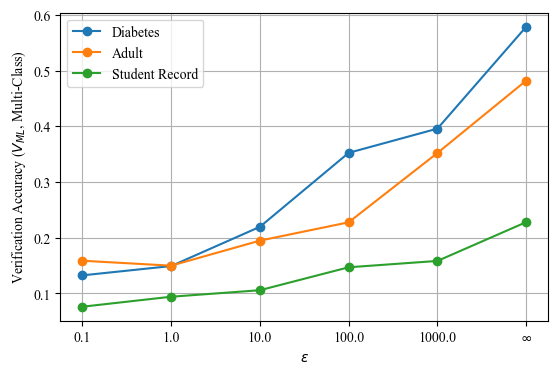

In [5]:
import matplotlib.pyplot as plt

# Configure matplotlib for Times New Roman font and 10-point size
plt.rc('font', family='Times New Roman', size=10)
plt.rc('axes', titlesize=10)  # Font size of the axes title
plt.rc('axes', labelsize=10)  # Font size of the x and y labels
plt.rc('xtick', labelsize=10)  # Font size of the x tick labels
plt.rc('ytick', labelsize=10)  # Font size of the y tick labels
plt.rc('legend', fontsize=10)  # Font size of the legend
plt.rc('figure', titlesize=10)  # Font size of the figure title

# Define the dataset names for better readability in the legend
dataset_names = {
    '891': 'Diabetes',
    '2': 'Adult',
    '697': 'Student Record'
}

# Plot the results
plt.figure(figsize=(6.3, 4))

# Loop through each dataset and plot its accuracy results against epsilon values
for dataset_id in dataset_id_list:
    plt.plot(epsilon_list, accuracy_results[dataset_id], marker='o', label=dataset_names[dataset_id])

# Ensure the ticks align with the data points and label the epsilon values
plt.xticks(epsilon_list, labels=['0.1', '1.0', '10.0', '100.0', '1000.0', r'$\infty$'])

# Customize axis labels and the legend
plt.xlabel(r'$\epsilon$')  # x-axis: epsilon values
plt.ylabel(r'Verification Accuracy ($V_{ML}$, Multi-Class)')  # y-axis: verification accuracy
plt.legend(loc='upper left', fontsize=10)  # Custom legend title and location
plt.grid(True)  # Add a grid for better readability

plt.savefig(f'plot_VML_Multi_lime_logres.pdf', format='pdf')

plt.show()

In [6]:
# Initialize a dictionary to store accuracies for plotting
pairwise_accuracy_results = {dataset_id: {f"0_vs_{i}": [] for i in range(1, 15)} for dataset_id in dataset_id_list}
final_averaged_accuracies = {dataset_id: [] for dataset_id in dataset_id_list}

# Loop through all combinations of dataset_id, epsilon, and case_id
for dataset_id in dataset_id_list:
    for epsilon in epsilon_list:
        total_accuracy = 0  # Accumulate accuracy across repeats and pairs

        for rep in repeat_list:  # Outer loop for repeats
            dataframes_r = []
            dataframes_v = []

            for case_id in case_id_list:
                # Construct the exact file names including the repeat number
                file_r = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_resR_case{case_id}_rep{rep}.csv')
                file_v = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_resV_case{case_id}_rep{rep}.csv')

                # Check if the file exists before trying to read it
                if os.path.exists(file_r):
                    df_r = pd.read_csv(file_r)  # Read the CSV file into a DataFrame
                    dataframes_r.append(df_r)
                else:
                    print(f"File {file_r} not found.")

                if os.path.exists(file_v):
                    df_v = pd.read_csv(file_v)  # Read the CSV file into a DataFrame
                    dataframes_v.append(df_v)
                else:
                    print(f"File {file_v} not found.")
    
            if dataframes_r and dataframes_v:
                df_r = pd.concat(dataframes_r, ignore_index=True)
                df_v = pd.concat(dataframes_v, ignore_index=True)
    
                # Iterate over each incorrect label (1 to 14) for pairwise comparison
                for incorrect_label in range(1, 15):  
                    # Filter to only keep rows where case is either 0 or the current incorrect_label
                    df_train_pair = df_v[df_v['case'].isin([0, incorrect_label])]
                    df_test_pair = df_r[df_r['case'].isin([0, incorrect_label])]

                    # Train and evaluate model for this pair
                    X_train = df_train_pair.drop(columns=['case'])
                    y_train = df_train_pair['case']
                    
                    X_test = df_test_pair.drop(columns=['case'])
                    y_test = df_test_pair['case']

                    clf = RandomForestClassifier(random_state=42)
                    clf.fit(X_train, y_train)
                    
                    y_pred = clf.predict(X_test)
                    
                    # Calculate and store accuracy for the pair
                    accuracy = accuracy_score(y_test, y_pred)
                    total_accuracy += accuracy

                    print(f"dataset{dataset_id}_eps{epsilon}_0_vs_{incorrect_label}_rep{rep}")
                    print("Verification Accuracy:", accuracy)

                    # Store pairwise accuracy
                    pairwise_accuracy_results[dataset_id][f"0_vs_{incorrect_label}"].append(accuracy)

        # Calculate average accuracy over all pairs and repeats for this epsilon
        average_accuracy = total_accuracy / (len(repeat_list) * 14)  # 14 pairwise comparisons
        final_averaged_accuracies[dataset_id].append(average_accuracy)

        print(f"Average Verification Accuracy for dataset{dataset_id}_eps{epsilon}: {average_accuracy}")

dataset891_eps0.1_0_vs_1_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_2_rep0
Verification Accuracy: 0.583
dataset891_eps0.1_0_vs_3_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_4_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_5_rep0
Verification Accuracy: 0.9782
dataset891_eps0.1_0_vs_6_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_7_rep0
Verification Accuracy: 0.5422
dataset891_eps0.1_0_vs_8_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_9_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_10_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_11_rep0
Verification Accuracy: 0.9771
dataset891_eps0.1_0_vs_12_rep0
Verification Accuracy: 0.9777
dataset891_eps0.1_0_vs_13_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_14_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_1_rep1
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_2_rep1
Verification Accuracy: 0.5002
dataset891_eps0.1_0_vs_3_rep1
Verification Accuracy: 0.5
dataset89

In [7]:
# Convert accuracy_results dictionary to a DataFrame
accuracy_df = pd.DataFrame(final_averaged_accuracies, index=epsilon_list)

# Save to CSV
accuracy_df.to_csv('accuracy_results_lime_logres_vml_binary.csv', index_label='epsilon')

print("Results saved to accuracy_results_lime_logres_vml_binary.csv")

Results saved to accuracy_results_lime_logres_vml_binary.csv


In [8]:
final_averaged_accuracies = pd.read_csv('accuracy_results_lime_logres_vml_binary.csv', index_col='epsilon')

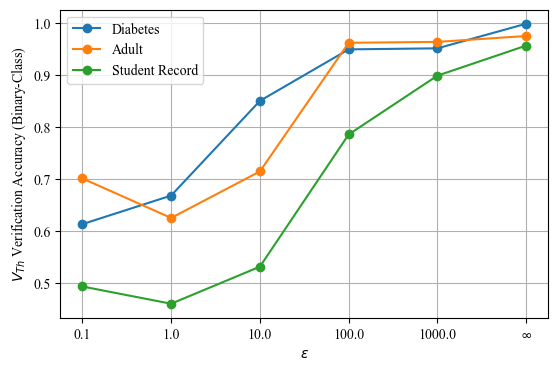

In [9]:
# Plot the results using previous plotting configuration
plt.rc('font', family='Times New Roman', size=10)
plt.rc('axes', titlesize=10)  # Font size of the axes title
plt.rc('axes', labelsize=10)  # Font size of the x and y labels
plt.rc('xtick', labelsize=10)  # Font size of the x tick labels
plt.rc('ytick', labelsize=10)  # Font size of the y tick labels
plt.rc('legend', fontsize=10)  # Font size of the legend
plt.rc('figure', titlesize=10)  # Font size of the figure title

dataset_names = {
    '891': 'Diabetes',
    '2': 'Adult',
    '697': 'Student Record'
}

# Plot the results
plt.figure(figsize=(6.3, 4))

for dataset_id in dataset_id_list:
    plt.plot(epsilon_list, final_averaged_accuracies[dataset_id], marker='o', label=dataset_names.get(dataset_id, dataset_id))

# Ensure the ticks align with the data points
plt.xticks(epsilon_list, labels=['0.1', '1.0', '10.0', '100.0', '1000.0', r'$\infty$'])

# Customize the legend text and labels
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'$V_{Th}$ Verification Accuracy (Binary-Class)')
plt.legend(loc='upper left', fontsize=10)  # Custom legend title and location
plt.grid(True)

plt.savefig(f'plot_VML_Binary_lime_logres.pdf', format='pdf')

plt.show()